<a href="https://colab.research.google.com/github/Anuskaghosh/Skin-cancer-detection/blob/main/Skin_Cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!pip install tensorflow
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Dropout




In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images")

print("Path to dataset files:", path)


Using Colab cache for faster access to the 'melanoma-skin-cancer-dataset-of-10000-images' dataset.
Path to dataset files: /kaggle/input/melanoma-skin-cancer-dataset-of-10000-images


In [ ]:
!kaggle datasets download -d hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images


Dataset URL: https://www.kaggle.com/datasets/hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images
License(s): CC0-1.0
  0% 0.00/98.7M [00:00<?, ?B/s]
100% 98.7M/98.7M [00:00<00:00, 1.62GB/s]


In [ ]:
!unzip /content/melanoma-skin-cancer-dataset-of-10000-images.zip -d /content/skin_cancer_dataset



Streaming output truncated to the last 5000 lines.
  inflating: /content/skin_cancer_dataset/melanoma_cancer_dataset/train/benign/melanoma_643.jpg  
  inflating: /content/skin_cancer_dataset/melanoma_cancer_dataset/train/benign/melanoma_644.jpg  
  inflating: /content/skin_cancer_dataset/melanoma_cancer_dataset/train/benign/melanoma_645.jpg  
  inflating: /content/skin_cancer_dataset/melanoma_cancer_dataset/train/benign/melanoma_646.jpg  
  inflating: /content/skin_cancer_dataset/melanoma_cancer_dataset/train/benign/melanoma_647.jpg  
  inflating: /content/skin_cancer_dataset/melanoma_cancer_dataset/train/benign/melanoma_648.jpg  
  inflating: /content/skin_cancer_dataset/melanoma_cancer_dataset/train/benign/melanoma_649.jpg  
  inflating: /content/skin_cancer_dataset/melanoma_cancer_dataset/train/benign/melanoma_65.jpg  
  inflating: /content/skin_cancer_dataset/melanoma_cancer_dataset/train/benign/melanoma_650.jpg  
  inflating: /content/skin_cancer_dataset/melanoma_cancer_dataset/tr

In [ ]:
#=============================================================================#
# 1) Imports and basic setup
#=============================================================================#
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns


# Reproducibility (not absolute but helps)
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


# Path to dataset (change if needed)
DATA_DIR = '/content/skin_cancer_dataset/melanoma_cancer_dataset'


# Image settings
IMG_SIZE = (224, 224) # VGG16 expects 224x224
BATCH_SIZE = 32

In [ ]:
#=============================================================================#
# 2) Set up data generators (train/val/test split)
#=============================================================================#
# We use a directory structure where each class is a subfolder.
# Keras flow_from_directory will infer class labels from folder names.


# We'll create a single ImageDataGenerator that will be used to split data by validation_split.
train_val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2, # 20% validation split from training files
    rotation_range=25,
    width_shift_range=0.12,
    height_shift_range=0.12,
    shear_range=0.12,
    zoom_range=0.12,
    horizontal_flip=True,
    vertical_flip=False,
    fill_mode='nearest'
)


# For test set we only rescale
test_datagen = ImageDataGenerator(rescale=1./255)


train_generator = train_val_datagen.flow_from_directory(
    os.path.join(DATA_DIR, 'train'), # Updated path to point to the 'train' subdirectory
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=SEED
)


val_generator = train_val_datagen.flow_from_directory(
    os.path.join(DATA_DIR, 'train'), # Updated path to point to the 'train' subdirectory
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=True,
    seed=SEED
)


# If you have a separate test folder, set TEST_DIR and use test_datagen.flow_from_directory
# Otherwise we will use the validation set as 'test' for the final confusion matrix (not ideal but common if no separate test).
TEST_DIR = os.path.join(DATA_DIR, 'test') # set to the 'test' subdirectory
if TEST_DIR:
    test_generator = test_datagen.flow_from_directory(
        TEST_DIR,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False
    )
else:
    # Use validation generator (but ensure shuffle=False for consistent predictions)
    print('Found classes:', train_generator.class_indices)

Found 7684 images belonging to 2 classes.
Found 1921 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [ ]:
#=============================================================================#
# 3) Build the model (VGG16 base + new head)
#=============================================================================#
# We use VGG16(weights='imagenet', include_top=False) and attach a small classifier head.
# To avoid overfitting:
# - start with base layers frozen
# - add GlobalAveragePooling to reduce parameters
# - add BatchNorm and Dropout
# - use L2 or dropout if needed

NUM_CLASSES = 2 # Defined based on the number of classes found by data generators

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
# Freeze base
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x) # converts feature maps -> vector
x = BatchNormalization()(x)
# Dense layer (small) + dropout
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
# Final classification layer
outputs = Dense(NUM_CLASSES, activation='softmax')(x)


model = Model(inputs=base_model.input, outputs=outputs)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
#=============================================================================#
# 4) Compile model
#=============================================================================#
# Use categorical cross-entropy for multi-class. If binary with 2 classes you can also use binary_crossentropy
# Mathematical: loss L = - sum_{i=1}^C y_i log(p_i), where p = softmax(z)


initial_lr = 1e-4
opt = Adam(learning_rate=initial_lr)
model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])


model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           51

 Total params: 14,848,578 (56.64 MB)

 Trainable params: 132,866 (519.01 KB)

 Non-trainable params: 14,715,712 (56.14 MB)

In [ ]:
#=============================================================================#
# 5) Callbacks
#=============================================================================#
callbacks = [
EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
ModelCheckpoint('best_vgg16_skin.h5', monitor='val_loss', save_best_only=True, verbose=1)
]


In [ ]:

# 6) Class weights (address class imbalance)
#=============================================================================#
# Compute simple class weights from train_generator
from collections import Counter
train_counts = Counter(train_generator.classes)
max_count = float(max(train_counts.values()))
class_weight = {i: max_count/float(c) for i,c in train_counts.items()}
print('Class weights:', class_weight)

Class weights: {np.int32(0): 1.0, np.int32(1): 1.0857763300760044}


In [ ]:
#=============================================================================#
# 7) Train the top classifier head first
#=============================================================================#
EPOCHS_HEAD = 12
history_head = model.fit(
train_generator,
steps_per_epoch=train_generator.samples // BATCH_SIZE,
validation_data=val_generator,
validation_steps=val_generator.samples // BATCH_SIZE,
epochs=EPOCHS_HEAD,
callbacks=callbacks,
class_weight=class_weight
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/12
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step - accuracy: 0.7044 - loss: 0.6217
Epoch 1: val_loss improved from inf to 0.53500, saving model to best_vgg16_skin.h5


240/240 ━━━━━━━━━━━━━━━━━━━━ 146s 545ms/step - accuracy: 0.7047 - loss: 0.6214 - val_accuracy: 0.8073 - val_loss: 0.5350 - learning_rate: 1.0000e-04
Epoch 2/12
  1/240 ━━━━━━━━━━━━━━━━━━━━ 39s 164ms/step - accuracy: 0.7188 - loss: 0.5135

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_loss improved from 0.53500 to 0.53329, saving model to best_vgg16_skin.h5


...

240/240 ━━━━━━━━━━━━━━━━━━━━ 25s 104ms/step - accuracy: 0.7188 - loss: 0.5758 - val_accuracy: 0.8703 - val_loss: 0.3160 - learning_rate: 1.0000e-04
Epoch 7/12
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - accuracy: 0.8478 - loss: 0.3623
Epoch 7: val_loss improved from 0.31596 to 0.29622, saving model to best_vgg16_skin.h5


240/240 ━━━━━━━━━━━━━━━━━━━━ 125s 520ms/step - accuracy: 0.8478 - loss: 0.3622 - val_accuracy: 0.8745 - val_loss: 0.2962 - learning_rate: 1.0000e-04
Epoch 8/12
  1/240 ━━━━━━━━━━━━━━━━━━━━ 40s 168ms/step - accuracy: 0.8750 - loss: 0.3257
Epoch 8: val_loss did not improve from 0.29622
240/240 ━━━━━━━━━━━━━━━━━━━━ 25s 103ms/step - accuracy: 0.8750 - loss: 0.3257 - val_accuracy: 0.8771 - val_loss: 0.3078 - learning_rate: 1.0000e-04
Epoch 9/12
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.8669 - loss: 0.3341
Epoch 9: val_loss improved from 0.29622 to 0.29071, saving model to best_vgg16_skin.h5


240/240 ━━━━━━━━━━━━━━━━━━━━ 127s 527ms/step - accuracy: 0.8669 - loss: 0.3342 - val_accuracy: 0.8797 - val_loss: 0.2907 - learning_rate: 1.0000e-04
Epoch 10/12
  1/240 ━━━━━━━━━━━━━━━━━━━━ 40s 169ms/step - accuracy: 0.8750 - loss: 0.2276
Epoch 10: val_loss did not improve from 0.29071
240/240 ━━━━━━━━━━━━━━━━━━━━ 25s 104ms/step - accuracy: 0.8750 - loss: 0.2276 - val_accuracy: 0.8854 - val_loss: 0.2908 - learning_rate: 1.0000e-04
Epoch 11/12
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - accuracy: 0.8546 - loss: 0.3299
Epoch 11: val_loss improved from 0.29071 to 0.27843, saving model to best_vgg16_skin.h5


240/240 ━━━━━━━━━━━━━━━━━━━━ 175s 518ms/step - accuracy: 0.8547 - loss: 0.3299 - val_accuracy: 0.8896 - val_loss: 0.2784 - learning_rate: 1.0000e-04
Epoch 12/12
  1/240 ━━━━━━━━━━━━━━━━━━━━ 40s 170ms/step - accuracy: 0.9062 - loss: 0.2869
Epoch 12: val_loss improved from 0.27843 to 0.27697, saving model to best_vgg16_skin.h5


240/240 ━━━━━━━━━━━━━━━━━━━━ 25s 104ms/step - accuracy: 0.9062 - loss: 0.2869 - val_accuracy: 0.8833 - val_loss: 0.2770 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 12.


In [ ]:
#=============================================================================#
# 8) Fine-tune: unfreeze last block(s) of VGG16
#=============================================================================#
# Unfreeze last convolutional block for fine-tuning
for layer in base_model.layers:
    # Example: unfreeze last 4 conv layers
    if layer.name.startswith('block5'):
        layer.trainable = True
    else:
        layer.trainable = False


# Recompile with lower LR
model.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])


EPOCHS_FINE = 10
history_fine = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    validation_data=val_generator,
    validation_steps=val_generator.samples // BATCH_SIZE,
    epochs=EPOCHS_FINE,
    callbacks=callbacks,
    class_weight=class_weight
)

Epoch 1/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step - accuracy: 0.8851 - loss: 0.2710
Epoch 1: val_loss did not improve from 0.23319
240/240 ━━━━━━━━━━━━━━━━━━━━ 145s 585ms/step - accuracy: 0.8851 - loss: 0.2710 - val_accuracy: 0.8990 - val_loss: 0.2444 - learning_rate: 1.0000e-05
Epoch 2/10
  1/240 ━━━━━━━━━━━━━━━━━━━━ 45s 192ms/step - accuracy: 0.9375 - loss: 0.1150
Epoch 2: val_loss did not improve from 0.23319
240/240 ━━━━━━━━━━━━━━━━━━━━ 25s 102ms/step - accuracy: 0.9375 - loss: 0.1150 - val_accuracy: 0.8948 - val_loss: 0.2527 - learning_rate: 1.0000e-05
Epoch 3/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.9058 - loss: 0.2409
Epoch 3: val_loss did not improve from 0.23319
240/240 ━━━━━━━━━━━━━━━━━━━━ 126s 524ms/step - accuracy: 0.9058 - loss: 0.2409 - val_accuracy: 0.9078 - val_loss: 0.2359 - learning_rate: 1.0000e-05
Epoch 4/10
  1/240 ━━━━━━━━━━━━━━━━━━━━ 46s 193ms/step - accuracy: 0.9062 - loss: 0.1864
Epoch 4: val_loss did not improve from 0.23319
240/240 ━━━━

240/240 ━━━━━━━━━━━━━━━━━━━━ 125s 522ms/step - accuracy: 0.8942 - loss: 0.2548 - val_accuracy: 0.9068 - val_loss: 0.2172 - learning_rate: 1.0000e-05
Epoch 6/10
  1/240 ━━━━━━━━━━━━━━━━━━━━ 46s 196ms/step - accuracy: 0.9062 - loss: 0.3338
Epoch 6: val_loss improved from 0.21721 to 0.21389, saving model to best_vgg16_skin.h5


240/240 ━━━━━━━━━━━━━━━━━━━━ 25s 103ms/step - accuracy: 0.9062 - loss: 0.3338 - val_accuracy: 0.9115 - val_loss: 0.2139 - learning_rate: 1.0000e-05
Epoch 7/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.9147 - loss: 0.2227
Epoch 7: val_loss improved from 0.21389 to 0.21020, saving model to best_vgg16_skin.h5


240/240 ━━━━━━━━━━━━━━━━━━━━ 126s 525ms/step - accuracy: 0.9147 - loss: 0.2227 - val_accuracy: 0.9193 - val_loss: 0.2102 - learning_rate: 1.0000e-05
Epoch 8/10
  1/240 ━━━━━━━━━━━━━━━━━━━━ 45s 190ms/step - accuracy: 0.9375 - loss: 0.2122
Epoch 8: val_loss did not improve from 0.21020
240/240 ━━━━━━━━━━━━━━━━━━━━ 25s 102ms/step - accuracy: 0.9375 - loss: 0.2122 - val_accuracy: 0.9115 - val_loss: 0.2118 - learning_rate: 1.0000e-05
Epoch 9/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step - accuracy: 0.9123 - loss: 0.2200
Epoch 9: val_loss improved from 0.21020 to 0.20038, saving model to best_vgg16_skin.h5


240/240 ━━━━━━━━━━━━━━━━━━━━ 125s 520ms/step - accuracy: 0.9123 - loss: 0.2200 - val_accuracy: 0.9187 - val_loss: 0.2004 - learning_rate: 1.0000e-05
Epoch 10/10
  1/240 ━━━━━━━━━━━━━━━━━━━━ 45s 191ms/step - accuracy: 0.8750 - loss: 0.2233
Epoch 10: val_loss did not improve from 0.20038
240/240 ━━━━━━━━━━━━━━━━━━━━ 24s 102ms/step - accuracy: 0.8750 - loss: 0.2233 - val_accuracy: 0.9167 - val_loss: 0.2063 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 9.


32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 284ms/step
Confusion matrix:
 [[483  17]
 [ 73 427]]


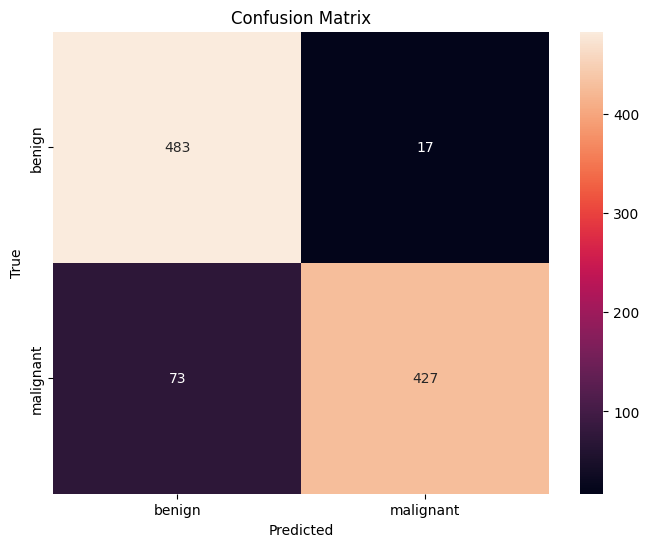


Classification Report:

              precision    recall  f1-score   support

      benign       0.87      0.97      0.91       500
   malignant       0.96      0.85      0.90       500

    accuracy                           0.91      1000
   macro avg       0.92      0.91      0.91      1000
weighted avg       0.92      0.91      0.91      1000



In [ ]:
#=============================================================================#
# 9) Evaluation and confusion matrix
#=============================================================================#

# Fix: steps must be an integer
steps = len(test_generator)

# Get predictions (no shuffle in test generator)
preds = model.predict(test_generator, steps=steps)

# Convert predicted probabilities to class indices
y_pred = np.argmax(preds, axis=1)
y_true = test_generator.classes

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion matrix:\n", cm)

# Plot confusion matrix
plt.figure(figsize=(8,6))
labels = list(test_generator.class_indices.keys())
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=labels))


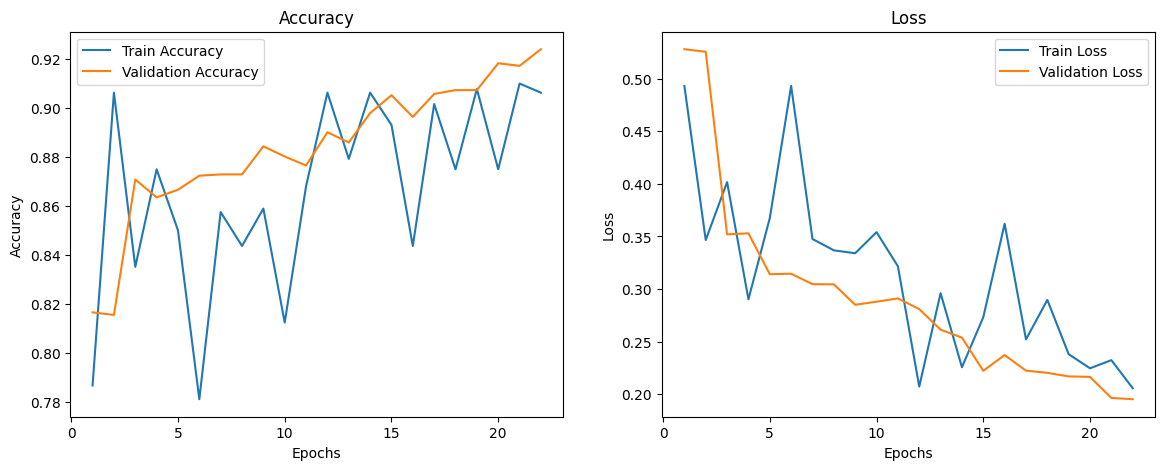

In [ ]:
#=============================================================================#
# 10) Training curves
#=============================================================================#

def plot_history(h1, h2=None):
    # Extract metrics from first history
    acc = h1.history['accuracy']
    val_acc = h1.history['val_accuracy']
    loss = h1.history['loss']
    val_loss = h1.history['val_loss']

    # If a second history exists, append it
    if h2 is not None:
        acc = acc + h2.history['accuracy']
        val_acc = val_acc + h2.history['val_accuracy']
        loss = loss + h2.history['loss']
        val_loss = val_loss + h2.history['val_loss']

    # Total epochs
    epochs = range(1, len(acc) + 1)

    # Plot training vs validation accuracy
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Train Accuracy')
    plt.plot(epochs, val_acc, label='Validation Accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot training vs validation loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Train Loss')
    plt.plot(epochs, val_loss, label='Validation Loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()


# Call the function
plot_history(history_head, history_fine)


In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

IMG_SIZE = (224, 224)

def grad_cam(model, img_array, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap) + 1e-8

    return heatmap



def show_gradcam(image_path):
    img = tf.keras.preprocessing.image.load_img(image_path, target_size=IMG_SIZE)
    img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    heatmap = grad_cam(model, img_array, 'block5_conv3')

    img = cv2.imread(image_path)
    img = cv2.resize(img, IMG_SIZE)

    heatmap = cv2.resize(heatmap, IMG_SIZE)
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)

    plt.figure(figsize=(6, 6))
    plt.imshow(cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("Grad-CAM Explanation")
    plt.show()


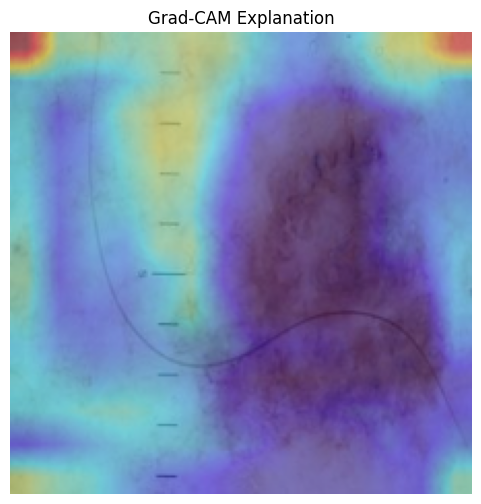

In [ ]:
show_gradcam(
    "/content/skin_cancer_dataset/melanoma_cancer_dataset/test/malignant/melanoma_10105.jpg"
)



In [ ]:
#=============================================================================#
# 11) Save final model
#=============================================================================#
model.save('vgg16_skin_classifier_final.h5')

In [ ]:
#=============================================================================#
# 12) Quick prediction helper
#=============================================================================#
from tensorflow.keras.preprocessing import image
import numpy as np

def predict_image(path, model, img_size=IMG_SIZE, class_indices=train_generator.class_indices):
    # Load the image and resize it to the same size as training images
    img = image.load_img(path, target_size=img_size)

    # Convert to array and scale to [0,1]
    x = image.img_to_array(img) / 255.0

    # Expand dims: (height, width, channels) -> (1, height, width, channels)
    x = np.expand_dims(x, axis=0)

    # Predict probabilities
    p = model.predict(x)

    # Choose highest probability class
    idx = np.argmax(p, axis=1)[0]

    # Reverse class index mapping
    inv_map = {v: k for k, v in class_indices.items()}

    # Return predicted label and confidence score
    return inv_map[idx], float(p[0][idx])


In [ ]:
def predict_with_threshold(image_path, model, threshold=0.3):
    img = tf.keras.preprocessing.image.load_img(image_path, target_size=IMG_SIZE)
    img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    preds = model.predict(img_array)[0]

    benign_prob = preds[0]
    malignant_prob = preds[1]

    if malignant_prob > threshold:
        label = "malignant"
        confidence = malignant_prob
    else:
        label = "benign"
        confidence = benign_prob

    print("Prediction:", label)
    print("Confidence:", round(confidence * 100, 2), "%")
    print("Malignant probability:", round(malignant_prob * 100, 2), "%")

    return label, confidence


In [ ]:
import os

test_path = "/content/skin_cancer_dataset/melanoma_cancer_dataset/test"

for root, dirs, files in os.walk(test_path):
    for file in files:
        if file.endswith((".jpg", ".jpeg", ".png")):
            print(os.path.join(root, file))
            break   # prints first image only


/content/skin_cancer_dataset/melanoma_cancer_dataset/test/benign/melanoma_9802.jpg
/content/skin_cancer_dataset/melanoma_cancer_dataset/test/malignant/melanoma_10270.jpg


In [ ]:
predict_image(
    "/content/skin_cancer_dataset/melanoma_cancer_dataset/test/benign/melanoma_10000.jpg",
    model
)



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


('benign', 0.9657084345817566)

In [ ]:
predict_image("/content/skin_cancer_dataset/melanoma_cancer_dataset/test/malignant/melanoma_10108.jpg",
              model
            )

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


('benign', 0.9297446012496948)

In [ ]:
from google.colab import files
files.download('/content/best_vgg16_skin.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>